In [1]:
import os 
import numpy as np 
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense , Dropout,Flatten,Rescaling
import pennylane as qml
from pennylane import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Input
from tensorflow.keras import Model
import torch
import torch.nn as nn
import torch.nn.functional as F
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import Estimator

In [2]:
from qiskit.circuit import ParameterVector, QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

def create_multiclass_pqc(num_qubits=6):
    x = ParameterVector("x", num_qubits)
    theta = ParameterVector("θ", num_qubits)

    qc = QuantumCircuit(num_qubits)

    # Data encoding (angle encoding + entanglement)
    for i in range(num_qubits):
        qc.h(i)
        qc.ry(x[i], i)

    # Entanglement layer
    for i in range(num_qubits - 1):
        qc.cz(i, i + 1)

    # Trainable parameters
    for i in range(num_qubits):
        qc.ry(theta[i], i)

    # Create observables: Pauli-Z on each qubit separately
    observables = [SparsePauliOp('I' * i + 'Z' + 'I' * (num_qubits - i - 1)) for i in range(num_qubits)]

    return qc, list(x), list(theta), observables


class MultiClassCQCNN(nn.Module):
    def __init__(self, num_qubits=6):
        super(MultiClassCQCNN, self).__init__()
        self.num_qubits = num_qubits

        # Classical CNN
        self.conv1 = nn.Conv2d(1, 2, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(2, 4, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(7056, num_qubits)


        # Quantum Circuit
        qc, input_params, weight_params, observables = create_multiclass_pqc(num_qubits)
        estimator = Estimator()
        qnn = EstimatorQNN(
            circuit=qc,
            input_params=input_params,
            weight_params=weight_params,
            observables=observables,
            estimator=estimator,
            input_gradients=True,
        )
        self.q_layer = TorchConnector(qnn)

        # Final output layer for class logits
        self.fc_final = nn.Linear(num_qubits, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))  # (B, 2, 62, 62)
        x = self.pool2(F.relu(self.conv2(x)))  # (B, 4, 29, 29)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)  # (B, num_qubits)
        x = torch.tanh(x)  
        x = self.q_layer(x)  # (B, num_qubits) real-valued
        x = self.fc_final(x)  # (B,2)
        return x  # logits (for use with CrossEntropyLoss)

In [3]:
model = MultiClassCQCNN(num_qubits=6)
print(model)

MultiClassCQCNN(
  (conv1): Conv2d(1, 2, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(2, 4, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=7056, out_features=6, bias=True)
  (q_layer): TorchConnector()
  (fc_final): Linear(in_features=6, out_features=2, bias=True)
)


C:\Users\TAZIM\AppData\Local\Temp\ipykernel_14340\1363966171.py:45: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()
C:\Users\TAZIM\AppData\Local\Temp\ipykernel_14340\1363966171.py:46: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


In [4]:
model.load_state_dict(torch.load("qcnn_model.pt"))
model.eval()


MultiClassCQCNN(
  (conv1): Conv2d(1, 2, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(2, 4, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=7056, out_features=6, bias=True)
  (q_layer): TorchConnector()
  (fc_final): Linear(in_features=6, out_features=2, bias=True)
)

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries, felzenszwalb
from torchvision import transforms
import matplotlib.patches as mpatches

g:\AlzQuantum_QCNN\AlzQuantum\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((180, 180)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

base_dir = r"G:\AlzQuantum_QCNN\AlzQuantum\10000 sample_images"
full_dataset = datasets.ImageFolder(root=base_dir, transform=transform)

class_names = full_dataset.classes
print("Classes:", class_names)


train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

total_size = len(full_dataset)

train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducibility
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


batch_size = 10

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Classes: ['Moderate Demented', 'Non Demented']
Train: 7000, Val: 1500, Test: 1500


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, felzenszwalb
import random

def lime_on_test_loader(test_loader, model, device,
                        class_names=None,
                        num_samples=1000,
                        num_images=15,
                        save_path='lime_testloader_visualization.png'):
    """
    Apply LIME explanations on random images from a test loader.

    Args:
        test_loader: PyTorch DataLoader for test dataset
        model: trained model
        device: torch device
        class_names: list of class names
        num_samples: number of LIME samples per image
        num_images: how many random images to pick
        save_path: path to save final visualization
    """
    
    model.eval()
    model.to(device)
    
    # -------------------------------
    # 1️⃣ Collect all images and labels from loader
    # -------------------------------
    all_images, all_labels = [], []
    for imgs, labels in test_loader:
        all_images.append(imgs)
        all_labels.append(labels)
    
    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)
    
    total_images = all_images.shape[0]
    num_images = min(num_images, total_images)
    
    # -------------------------------
    # 2️⃣ Sample random indices
    # -------------------------------
    indices = random.sample(range(total_images), num_images)
    sampled_images = all_images[indices]
    sampled_labels = all_labels[indices]
    
    # -------------------------------
    # 3️⃣ Prepare LIME explainer
    # -------------------------------
    explainer = lime_image.LimeImageExplainer()
    
    def predict_for_lime(images):
        """
        Predict function for LIME: expects list of HxWx3 numpy images
        """
        batch = []
        for img in images:
            # Convert to grayscale (since model expects 1 channel)
            img_gray = np.mean(img, axis=-1)
            # Normalize to [-1,1] like in training
            img_tensor = torch.FloatTensor((img_gray - 0.5)/0.5).unsqueeze(0)
            batch.append(img_tensor)
        batch_tensor = torch.stack(batch).to(device)
        
        with torch.no_grad():
            logits = model(batch_tensor)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()
    
    # -------------------------------
    # 4️⃣ Plot setup
    # -------------------------------
    fig = plt.figure(figsize=(18, 6 * num_images))
    print(f"🎨 Running LIME on {num_images} random test images...\n")
    
    # -------------------------------
    # 5️⃣ Run LIME for each sampled image
    # -------------------------------
    for idx, (img_tensor, true_label) in enumerate(zip(sampled_images, sampled_labels)):
        # Convert to numpy H x W
        img_array = img_tensor.squeeze().cpu().numpy()
        # replicate channels for LIME (H x W x 3)
        img_array_3d = np.stack([img_array]*3, axis=-1)
        
        # Model prediction
        input_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=1)
            predicted_class = torch.argmax(probs, dim=1).item()
            confidence = probs[0, predicted_class].item()
        
        correct = predicted_class == true_label
        title_color = 'green' if correct else 'red'
        status = "✅ Correct" if correct else "❌ Wrong"
        print(f"Image {idx+1}: Predicted {class_names[predicted_class]} ({confidence*100:.1f}%) | {status}")
        
        # Superpixel segmentation
        segments = felzenszwalb(img_array_3d, scale=100, sigma=0.5, min_size=50)
        
        # LIME explanation
        explanation = explainer.explain_instance(
            img_array_3d,
            predict_for_lime,
            top_labels=2,
            hide_color=0,
            num_samples=num_samples,
            segmentation_fn=lambda x: segments
        )
        
        # Positive & negative masks
        temp_pos, mask_pos = explanation.get_image_and_mask(predicted_class,
                                                           positive_only=True,
                                                           num_features=10,
                                                           hide_rest=True)
        temp_neg, mask_neg = explanation.get_image_and_mask(predicted_class,
                                                           positive_only=False,
                                                           num_features=10,
                                                           hide_rest=True,
                                                           negative_only=True)
        
        row = idx * 3
        
        # === Original Image ===
        ax1 = plt.subplot(num_images, 3, row+1)
        ax1.imshow(img_array, cmap='gray')
        ax1.axis('off')
        ax1.set_title(f"GT: {class_names[true_label]}\nPred: {class_names[predicted_class]} ({confidence*100:.1f}%)",
                      fontsize=10, fontweight='bold', color=title_color)
        
        # === Positive Features ===
        ax2 = plt.subplot(num_images, 3, row+2)
        overlay_pos = img_array_3d.copy()
        overlay_pos[mask_pos>0] = [0,1,0]
        blended_pos = img_array_3d * 0.4 + overlay_pos * 0.6
        bounded_pos = mark_boundaries(blended_pos, mask_pos, color=(0,1,0), mode='thick')
        ax2.imshow(bounded_pos)
        ax2.axis('off')
        ax2.set_title("Positive Features", fontsize=10, fontweight='bold', color='green')
        
        # === Negative Features ===
        ax3 = plt.subplot(num_images, 3, row+3)
        overlay_neg = img_array_3d.copy()
        overlay_neg[mask_neg>0] = [1,0,0]
        blended_neg = img_array_3d * 0.4 + overlay_neg * 0.6
        bounded_neg = mark_boundaries(blended_neg, mask_neg, color=(1,0,0), mode='thick')
        ax3.imshow(bounded_neg)
        ax3.axis('off')
        ax3.set_title("Negative Features", fontsize=10, fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ LIME visualization saved to {save_path}")
    plt.show()
    print("🎉 Completed LIME explanations!")


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, felzenszwalb
from skimage import filters
import random

def lime_on_test_loader_brain_only(test_loader, model, device,
                                   class_names=None,
                                   num_samples=1000,
                                   num_images=15,
                                   save_path='lime_testloader_brain_visualization.png'):
    """
    Apply LIME explanations on random images from a test loader, masking out
    all areas outside the brain so that LIME only highlights relevant regions.
    
    Args:
        test_loader: PyTorch DataLoader for test dataset
        model: trained model
        device: torch device
        class_names: list of class names
        num_samples: number of LIME samples per image
        num_images: how many random images to pick
        save_path: path to save final visualization
    """
    model.eval()
    model.to(device)
    
    # -------------------------------
    # 1️⃣ Collect all images and labels from loader
    # -------------------------------
    all_images, all_labels = [], []
    for imgs, labels in test_loader:
        all_images.append(imgs)
        all_labels.append(labels)
    
    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)
    
    total_images = all_images.shape[0]
    num_images = min(num_images, total_images)
    
    # -------------------------------
    # 2️⃣ Sample random indices
    # -------------------------------
    indices = random.sample(range(total_images), num_images)
    sampled_images = all_images[indices]
    sampled_labels = all_labels[indices]
    
    # -------------------------------
    # 3️⃣ Prepare LIME explainer
    # -------------------------------
    explainer = lime_image.LimeImageExplainer()
    
    def predict_for_lime(images):
        """
        Predict function for LIME: expects list of HxWx3 numpy images
        """
        batch = []
        for img in images:
            # Convert to grayscale (model expects 1 channel)
            img_gray = np.mean(img, axis=-1)
            # Normalize to [-1,1] like in training
            img_tensor = torch.FloatTensor((img_gray - 0.5)/0.5).unsqueeze(0)
            batch.append(img_tensor)
        batch_tensor = torch.stack(batch).to(device)
        
        with torch.no_grad():
            logits = model(batch_tensor)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()
    
    # -------------------------------
    # 4️⃣ Plot setup
    # -------------------------------
    fig = plt.figure(figsize=(18, 6 * num_images))
    print(f"🎨 Running LIME on {num_images} random test images...\n")
    
    # -------------------------------
    # 5️⃣ Run LIME for each sampled image
    # -------------------------------
    for idx, (img_tensor, true_label) in enumerate(zip(sampled_images, sampled_labels)):
        img_array = img_tensor.squeeze().cpu().numpy()
        img_array_3d = np.stack([img_array]*3, axis=-1)
        
        # -------------------------------
        # Brain mask: threshold or Otsu
        # -------------------------------
        threshold = filters.threshold_otsu(img_array)
        brain_mask = img_array > threshold  # True for brain, False for background
        
        # Model prediction
        input_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=1)
            predicted_class = torch.argmax(probs, dim=1).item()
            confidence = probs[0, predicted_class].item()
        
        correct = predicted_class == true_label
        title_color = 'green' if correct else 'red'
        status = "✅ Correct" if correct else "❌ Wrong"
        print(f"Image {idx+1}: Predicted {class_names[predicted_class]} ({confidence*100:.1f}%) | {status}")
        
        # -------------------------------
        # Superpixel segmentation within brain
        # -------------------------------
        segments = felzenszwalb(img_array_3d, scale=100, sigma=0.5, min_size=50)
        # Mask out non-brain segments
        segments_masked = segments.copy()
        segments_masked[~brain_mask] = -1  # LIME ignores segment -1
        
        # LIME explanation
        explanation = explainer.explain_instance(
            img_array_3d,
            predict_for_lime,
            top_labels=2,
            hide_color=0,
            num_samples=num_samples,
            segmentation_fn=lambda x: segments_masked
        )
        
        # Positive & negative masks
        temp_pos, mask_pos = explanation.get_image_and_mask(predicted_class,
                                                           positive_only=True,
                                                           num_features=10,
                                                           hide_rest=True)
        temp_neg, mask_neg = explanation.get_image_and_mask(predicted_class,
                                                           positive_only=False,
                                                           num_features=10,
                                                           hide_rest=True,
                                                           negative_only=True)
        
        row = idx * 3
        
        # === Original Image ===
        ax1 = plt.subplot(num_images, 3, row+1)
        ax1.imshow(img_array, cmap='gray')
        ax1.axis('off')
        ax1.set_title(f"GT: {class_names[true_label]}\nPred: {class_names[predicted_class]} ({confidence*100:.1f}%)",
                      fontsize=10, fontweight='bold', color=title_color)
        
        # === Positive Features ===
        ax2 = plt.subplot(num_images, 3, row+2)
        overlay_pos = img_array_3d.copy()
        overlay_pos[mask_pos>0] = [0,1,0]
        blended_pos = img_array_3d * 0.4 + overlay_pos * 0.6
        bounded_pos = mark_boundaries(blended_pos, mask_pos, color=(0,1,0), mode='thick')
        ax2.imshow(bounded_pos)
        ax2.axis('off')
        ax2.set_title("Positive Features", fontsize=10, fontweight='bold', color='green')
        
        # === Negative Features ===
        ax3 = plt.subplot(num_images, 3, row+3)
        overlay_neg = img_array_3d.copy()
        overlay_neg[mask_neg>0] = [1,0,0]
        blended_neg = img_array_3d * 0.4 + overlay_neg * 0.6
        bounded_neg = mark_boundaries(blended_neg, mask_neg, color=(1,0,0), mode='thick')
        ax3.imshow(bounded_neg)
        ax3.axis('off')
        ax3.set_title("Negative Features", fontsize=10, fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ LIME visualization saved to {save_path}")
    plt.show()
    print("🎉 Completed LIME explanations!")


🎨 Running LIME on 5 random test images...

Image 1: Predicted Non Demented (100.0%) | ✅ Correct


100%|██████████| 500/500 [00:05<00:00, 94.64it/s] 
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Image 2: Predicted Non Demented (100.0%) | ✅ Correct


100%|██████████| 500/500 [00:05<00:00, 97.49it/s] 
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Image 3: Predicted Moderate Demented (99.9%) | ✅ Correct


...

Image 4: Predicted Non Demented (100.0%) | ✅ Correct


100%|██████████| 500/500 [00:05<00:00, 97.15it/s] 
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Image 5: Predicted Non Demented (98.1%) | ✅ Correct


100%|██████████| 500/500 [00:05<00:00, 94.54it/s] 
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].



✅ LIME visualization saved to lime_testloader_output.png


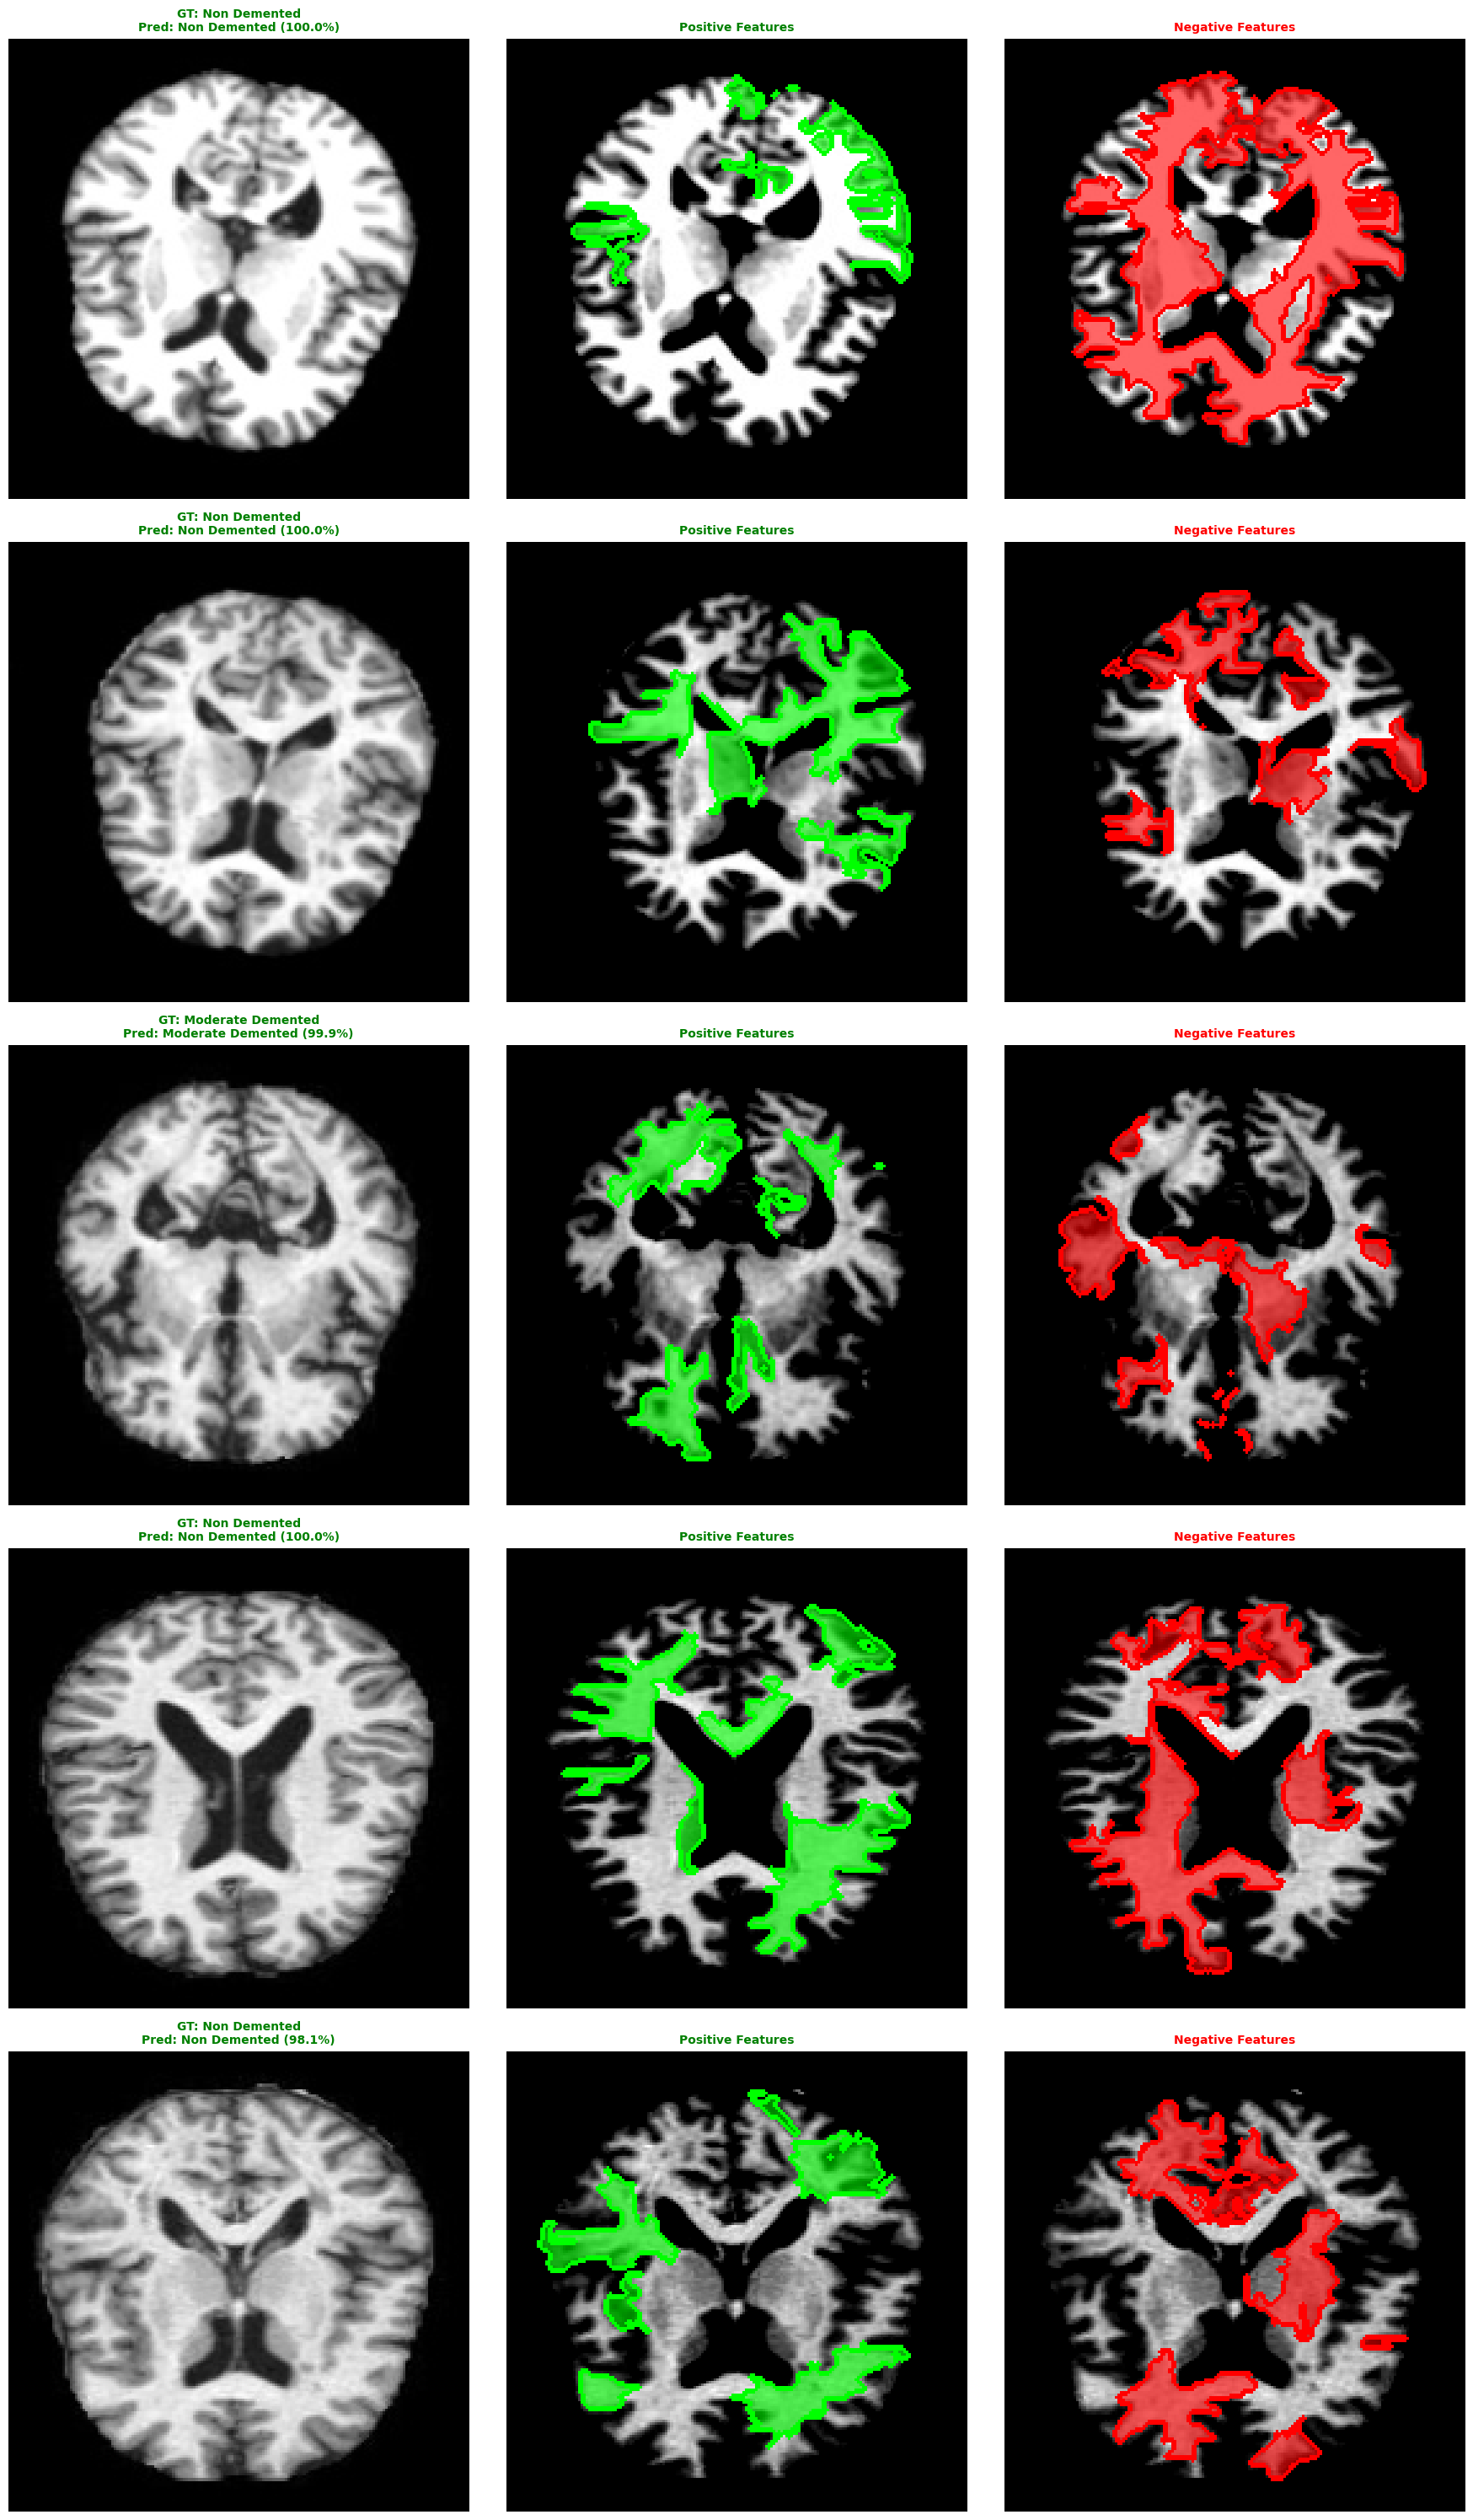

🎉 Completed LIME explanations!


In [17]:
# 1️⃣ Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2️⃣ Load your trained model
# model = torch.load("model.pt", map_location=device)
model.to(device)
model.eval()

# 3️⃣ Define class names (from your ImageFolder)
class_names = ['Moderate Demented', 'Non Demented']  # or use full_dataset.classes

# 4️⃣ Call LIME on test loader
lime_on_test_loader_brain_only(
    test_loader=test_loader,   # your DataLoader
    model=model,               # trained model
    device=device,
    class_names=class_names,
    num_samples=500,          # number of LIME samples
    num_images=5,             # how many random images from test loader
    save_path='lime_testloader_output.png'  # path to save visualization
)
